# FMA Baseline — MFCC → 2D CNN (Version 5: FFmpeg + CUDA→XPU→CPU fallback)

This baseline_mfcc_cnn_v5.ipynb is a modernized reimplementation of the official FMA notebook’s ConvNet on MFCC baseline, preserving the same core MFCC-as-2D-input CNN architecture while updating the data pipeline and training infrastructure - i.e it adds  modern engineering layers around it: ffmpeg decoding, cache/index parquet flow, tf.data, device fallback, cleaner model construction

Reproduces the MFCC-based 2D CNN baseline from the official FMA repository:
- **Reference:** `FMA/fma-repo/baselines.ipynb` §3.1 "ConvNet on MFCC"
- **Paper:** Li et al., "Automatic Musical Pattern Feature Extraction Using Convolutional Neural Network", IMECS 2010

**Architecture (faithful to the original):**

| Layer | Output shape |
|---|---|
| Input | `(13, 2582, 1)` — 13 MFCC × 2582 time frames |
| Conv2D(3, 13×10, stride 1×4) + ReLU | `(1, 644, 3)` |
| Conv2D(15, 1×10, stride 1×4) + ReLU | `(1, 159, 15)` |
| Conv2D(65, 1×10, stride 1×4) + ReLU | `(1, 38, 65)` |
| Flatten | `(2470,)` |
| Dense(16, softmax) | `(16,)` |

**Prerequisite:** run `build_manifest.py` first to generate the parquet splits in `MelCNN-MGR/data/processed/`.

## 1. Imports

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import os

warnings.filterwarnings("ignore", category=UserWarning)

# ── TensorFlow ────────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── sklearn ───────────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f"Python     : {sys.version.split()[0]}")
print(f"TensorFlow : {tf.__version__}")

2026-03-13 15:29:53.464406: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 15:29:53.981225: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-13 15:29:53.981716: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-13 15:29:54.035375: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-13 15:29:54.175492: I tensorflow/core/platform/cpu_feature_guar

Python     : 3.11.14
TensorFlow : 2.15.1


## Device runtime selection (CUDA → Intel XPU → CPU)

This notebook prefers hardware acceleration in this order:

1. **CUDA GPU** (`/GPU:0`) if available  
2. **Intel XPU** (`/XPU:0`) if available (requires **Intel Extension for TensorFlow — ITEX**)  
3. **CPU** (`/CPU:0`) as a safe fallback  

The selection is done once up-front and stored in `RUNTIME_DEVICE`.


## 2. Configuration & Hyperparameters

All tuneable knobs in one cell. Change `SUBSET` to `"small"` or `"large"` if you have those
manifests built. Set `CLEAR_CACHE = True` to force full MFCC re-extraction.

In [2]:

# ── Paths ─────────────────────────────────────────────────────────────────────
# Notebook lives in MelCNN-MGR/model_training/ — two levels up from workspace root
NOTEBOOK_DIR    = Path().resolve()                       # …/MelCNN-MGR/model_training
MELCNN_DIR      = NOTEBOOK_DIR.parent                    # …/MelCNN-MGR
WORKSPACE       = MELCNN_DIR.parent                      # …/machine-learning-1

PROCESSED_DIR   = MELCNN_DIR / "data" / "processed_baseline"      # manifest parquets
CACHE_DIR       = MELCNN_DIR / "cache"

# ── Per-run model directory ───────────────────────────────────────────────────
# Each training run saves its artifacts (model + run report) into a timestamped
# subdirectory so runs don't overwrite each other:
#   MelCNN-MGR/models/mfcc-cnn-<yyyymmdd-HHMMSS>/
#       baseline_mfcc_cnn.keras
#       run_report_<subset>.txt   ← config + architecture + history + eval results
#
# RUN_DIR is created at the start of Section 7 (training cell) so the timestamp
# reflects when training actually ran, not when the notebook was opened.
# Note: colons are not valid in Windows/NTFS paths (this workspace is on /mnt/d/).
MODELS_BASE_DIR = MELCNN_DIR / "models"                  # base — do not write here directly
RUN_DIR         = None                                    # set in Section 7

# ── Subset ────────────────────────────────────────────────────────────────────
SUBSET        = "tiny"   # "tiny" | "small" | "medium" | "large"
CLEAR_CACHE   = False     # set True to delete MFCC cache + indexes and re-extract


# ── Audio backend (Version 4) ─────────────────────────────────────────────────
# Global fallback policy:
#   - If ffmpeg is available, use it for ALL decoding (fast + robust for MP3).
#   - Otherwise, fall back to librosa.load for ALL decoding.
import shutil as _shutil
FFMPEG_AVAILABLE = _shutil.which("ffmpeg") is not None
AUDIO_BACKEND = "ffmpeg" if FFMPEG_AVAILABLE else "librosa"
print(f"[Audio] backend = {AUDIO_BACKEND} (ffmpeg_available={FFMPEG_AVAILABLE})")

# ── Performance knobs ─────────────────────────────────────────────────────────
# Feature extraction is CPU/I/O-bound. Biggest wins come from:
#   (1) parallelizing across files, and (2) caching per-track MFCCs.
NUM_WORKERS   = min(6, (os.cpu_count() or 8))   # tune 4–12 depending on disk/CPU

# ── Audio sanity checks (cheap, no stderr capture) ───────────────────────────
# We still skip unreadable files via try/except. These checks catch "bad-but-decodes"
# cases (NaNs, too-short clips, near-silent audio) without costly stderr piping.
MIN_SECONDS   = 1.0        # skip clips shorter than this after decoding
SKIP_SILENT   = False      # True → drop near-silent clips
SILENCE_PEAK  = 1e-4       # max(abs(y)) below this → "silent"
SILENCE_STD   = 1e-5       # std(y) below this → "silent"

# ── Cache layout (per-track) ──────────────────────────────────────────────────
# Per-track MFCC .npy files are keyed only by track_id and extraction params,
# so they are identical regardless of which subset the track belongs to.
#
# MFCC_CACHE_SHARED = True  (recommended)
#   All subsets (small / medium / tiny / …) read from and write to the same
#   directory: cache/mfcc/shared/<track_id>.npy
#   Benefit: switching subsets (e.g. medium → small) is instant — no re-extraction.
#   Note: CLEAR_CACHE=True will wipe the shared dir (all subsets). This is usually
#   the right behaviour (e.g. after changing N_MFCC or HOP_LENGTH).
#
# MFCC_CACHE_SHARED = False
#   Each subset gets its own directory: cache/mfcc/<subset>/<track_id>.npy
#   Use this only if you need to test different extraction params per subset.
MFCC_CACHE_SHARED = True
MFCC_CACHE_DIR = CACHE_DIR / "mfcc" / ("shared" if MFCC_CACHE_SHARED else SUBSET)

# Index parquets always remain per-subset (they record which tracks are usable
# for each subset's split, independent of the shared track cache):
#   cache/mfcc_index_<split>_<subset>.parquet

# ── Training hyperparameters ─────────────────────────────────────────────────
EPOCHS        = 30
BATCH_SIZE    = 16

# ── MFCC extraction params (must match cached MFCC files) ─────────────────────
SAMPLE_RATE   = 22050
N_MFCC        = 13
N_FFT         = 512
HOP_LENGTH    = 256
# 30 s @ 22 050 Hz → 661 500 samples → frames = 1 + (661500 - 512) // 256 = 2582
N_FRAMES      = 2582
MFCC_SHAPE    = (N_MFCC, N_FRAMES)    # (13, 2582)

# ── Reproducibility seed ─────────────────────────────────────────────────────
SEED = 42

import random
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"[Seed] SEED={SEED} applied to random / numpy / tensorflow")

# ── Global timer (starts here, used by every section below) ───────────────────
import time as _time_module
_T0             = _time_module.perf_counter()   # overall notebook start
_section_times  = {}                            # {section: seconds}

[Audio] backend = ffmpeg (ffmpeg_available=True)
[Seed] SEED=42 applied to random / numpy / tensorflow


In [3]:
_t0 = _time_module.perf_counter()

# ── Runtime device selection: CUDA → Intel XPU → CPU ──────────────────────────
# Global policy:
#   1) Prefer CUDA GPU if present and usable
#   2) Else prefer Intel XPU if ITEX is installed and XPU is present and usable
#   3) Else fall back to CPU
#
# NOTE: XPU devices usually appear only after importing intel_extension_for_tensorflow (ITEX).

import platform
import traceback

def _best_effort_set_memory_growth(tf, device_type: str):
    devs = tf.config.list_physical_devices(device_type)
    for d in devs:
        try:
            tf.config.experimental.set_memory_growth(d, True)
        except Exception:
            pass
    return devs

def _smoke_test_matmul(tf, device: str, n: int = 1024) -> tuple[bool, str]:
    """Tiny compute check to confirm the device actually works."""
    try:
        with tf.device(device):
            a = tf.random.normal([n, n])
            b = tf.random.normal([n, n])
            c = tf.matmul(a, b)
            _ = c[0, 0].numpy()
        return True, "ok"
    except Exception as e:
        return False, repr(e)

def configure_runtime_device(tf):
    # 0) Print basic environment info (helps debugging)
    print(f"Platform   : {platform.platform()}")
    print(f"TensorFlow : {tf.__version__}")

    # 1) CUDA GPU
    try:
        gpus = _best_effort_set_memory_growth(tf, "GPU")
    except Exception:
        gpus = []
    if gpus:
        ok, info = _smoke_test_matmul(tf, "/GPU:0", n=1024)
        if ok:
            return "/GPU:0", "cuda", [d.name for d in gpus], info
        else:
            print("CUDA present but failed smoke test →", info)

    # 2) Intel XPU (via ITEX)
    itex = None
    try:
        import intel_extension_for_tensorflow as itex  # noqa: F401
        # After importing ITEX, XPU devices (if any) should show up here.
        xpus = _best_effort_set_memory_growth(tf, "XPU")
    except Exception as e:
        xpus = []
        print("ITEX/XPU not available:", repr(e))

    if xpus:
        ok, info = _smoke_test_matmul(tf, "/XPU:0", n=1024)
        if ok:
            return "/XPU:0", "xpu", [d.name for d in xpus], info
        else:
            print("XPU present but failed smoke test →", info)

    # 3) CPU fallback
    return "/CPU:0", "cpu", [], "ok"

RUNTIME_DEVICE, BACKEND, ACCEL_NAMES, SMOKE_INFO = configure_runtime_device(tf)

print(f"Backend    : {BACKEND.upper()} ({RUNTIME_DEVICE})")
if ACCEL_NAMES:
    print(f"Devices    : {ACCEL_NAMES}")
else:
    print("Devices    : none detected → CPU fallback")
print(f"Smoke test : {SMOKE_INFO}")

_section_times["2. Device setup"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Device setup : {_section_times['2. Device setup']:.2f}s")


Platform   : Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
TensorFlow : 2.15.1


2026-03-13 15:31:37.002249: I tensorflow/core/common_runtime/next_pluggable_device/next_pluggable_device_factory.cc:118] Created 1 TensorFlow NextPluggableDevices. Physical device type: XPU


Backend    : XPU (/XPU:0)
Devices    : ['/physical_device:XPU:0']
Smoke test : ok

⏱  Device setup : 14.89s


## 3. Load Manifest Splits

Reads the pre-built parquet files produced by `build_manifest.py`. Each file contains only
`reason_code == OK` rows for the requested subset, with a flat column set
(`filepath`, `genre_top`, `split`, `artist_id`, `duration_s`, …).

In [4]:
_t0 = _time_module.perf_counter()

def load_manifest_splits(processed_dir: Path, subset: str):
    """Load train / val / test parquets produced by build_manifest.py."""
    def _load(name: str) -> pd.DataFrame:
        path = processed_dir / f"{name}_{subset}.parquet"
        if not path.exists():
            raise FileNotFoundError(
                f"Manifest parquet not found: {path}\n"
                "Run build_manifest.py first:\n"
                "  python MelCNN-MGR/preprocessing/build_manifest.py"
            )
        return pd.read_parquet(path)

    train_df = _load("train")
    val_df   = _load("val")
    test_df  = _load("test")
    return train_df, val_df, test_df


print("Loading manifest parquets …")
train_df, val_df, test_df = load_manifest_splits(PROCESSED_DIR, SUBSET)

print(f"  train : {len(train_df):>5,} rows")
print(f"  val   : {len(val_df):>5,} rows")
print(f"  test  : {len(test_df):>5,} rows")

# Collect all genres (sorted for reproducibility)
all_genres    = sorted(pd.concat([train_df, val_df, test_df])["genre_top"].unique().tolist())
N_CLASSES     = len(all_genres)
GENRE_CLASSES = all_genres
print(f"\n  Genres ({N_CLASSES}): {GENRE_CLASSES}")

label_enc = LabelEncoder().fit(GENRE_CLASSES)

_section_times["3. Load manifest"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Load manifest : {_section_times['3. Load manifest']:.2f}s")

Loading manifest parquets …
  train : 2,952 rows
  val   :   448 rows
  test  :   448 rows

  Genres (8): ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']

⏱  Load manifest : 1.07s


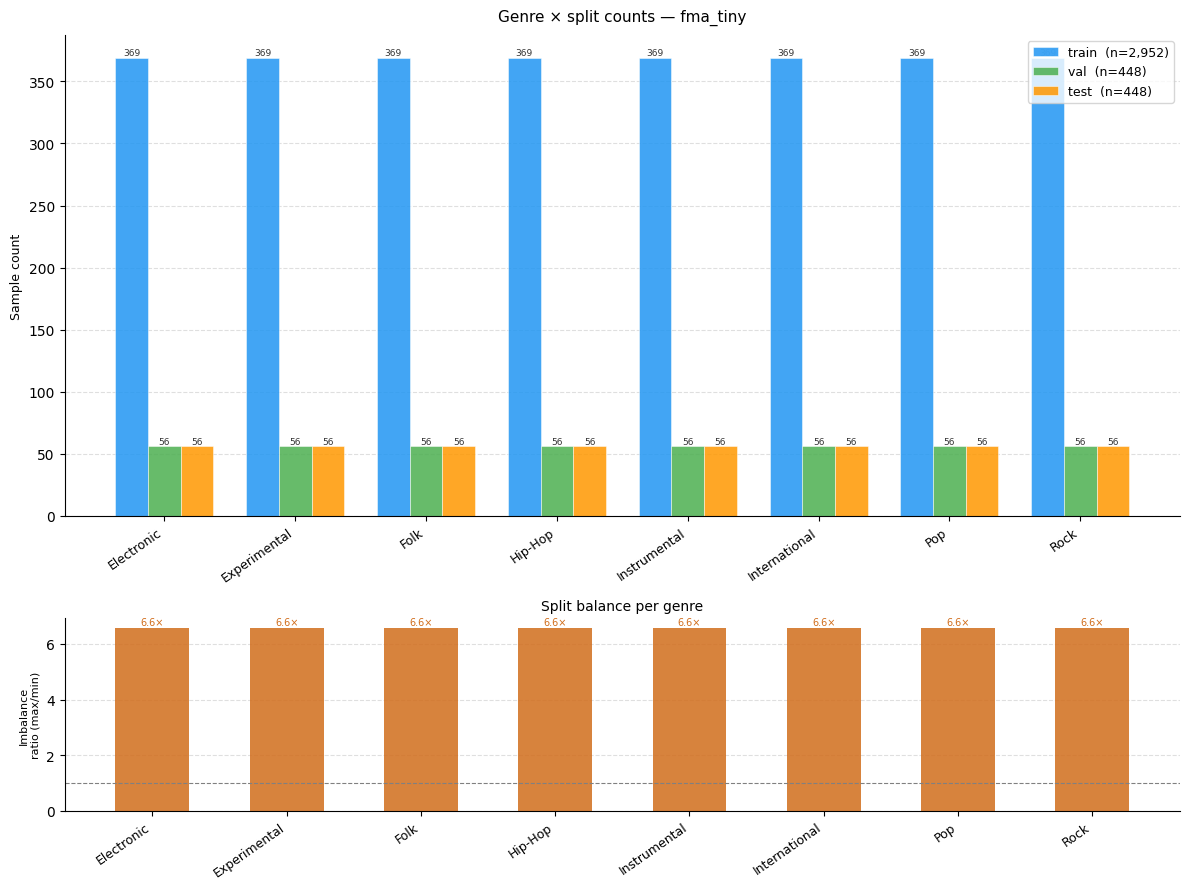

Most imbalanced genre across splits : Electronic  (ratio = 6.59×)
→ Significant imbalance detected — consider class-weighted loss or reporting Macro-F1 as the primary metric.

⏱  Genre distribution plot : 2.04s


In [5]:

_t0 = _time_module.perf_counter()

# ── Genre × split counts — Grouped Bar Chart ──────────────────────────────────
# X-axis: genres (sorted alphabetically)
# Each genre has three bars: train / val / test
# A secondary imbalance-ratio panel is kept below for quick diagnosis.

splits      = ["train", "val", "test"]
dfs         = [train_df, val_df, test_df]
split_colors = ["#2196F3", "#4CAF50", "#FF9800"]   # blue / green / orange

genres_sorted = sorted(all_genres)
n_genres      = len(genres_sorted)

# Build (n_genres × 3) count matrix
counts_matrix = np.array(
    [[df["genre_top"].value_counts().get(g, 0) for df in dfs] for g in genres_sorted],
    dtype=int,
)

# Imbalance ratio per genre (max / min across splits, guarded against zero)
row_max   = counts_matrix.max(axis=1).astype(float)
row_min   = np.where(counts_matrix.min(axis=1) == 0, 1, counts_matrix.min(axis=1)).astype(float)
imbalance = row_max / row_min

# ── Layout ────────────────────────────────────────────────────────────────────
fig, (ax_bar, ax_imb) = plt.subplots(
    2, 1,
    figsize=(max(12, n_genres * 0.9), 9),
    gridspec_kw={"height_ratios": [3, 1.2]},
)

# ── Top panel: grouped bar chart ───────────────────────────────────────────────
x       = np.arange(n_genres)
n_grps  = len(splits)
width   = 0.25
offsets = np.linspace(-(n_grps - 1) / 2, (n_grps - 1) / 2, n_grps) * width

for j, (split, color, offset) in enumerate(zip(splits, split_colors, offsets)):
    counts = counts_matrix[:, j]
    bars   = ax_bar.bar(x + offset, counts, width=width,
                        label=f"{split}  (n={counts.sum():,})",
                        color=color, alpha=0.85, edgecolor="white", linewidth=0.4)
    # Annotate bar tops with count value
    for bar, cnt in zip(bars, counts):
        if cnt > 0:
            ax_bar.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                str(cnt),
                ha="center", va="bottom", fontsize=6.5, color="#333333",
            )

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(genres_sorted, rotation=35, ha="right", fontsize=9)
ax_bar.set_ylabel("Sample count", fontsize=9)
ax_bar.set_title(f"Genre × split counts — fma_{SUBSET}", fontsize=11, pad=10)
ax_bar.legend(fontsize=9, loc="upper right")
for spine in ["top", "right"]:
    ax_bar.spines[spine].set_visible(False)
ax_bar.yaxis.grid(True, linestyle="--", alpha=0.4)
ax_bar.set_axisbelow(True)

# ── Bottom panel: imbalance ratio ─────────────────────────────────────────────
bar_colors = ["#d16d1b" if r > 1.5 else "#159dd3" for r in imbalance]
ax_imb.bar(x, imbalance, color=bar_colors, width=0.55, edgecolor="none", alpha=0.85)
ax_imb.axhline(1.0, color="grey", linewidth=0.8, linestyle="--")
ax_imb.set_xticks(x)
ax_imb.set_xticklabels(genres_sorted, rotation=35, ha="right", fontsize=9)
ax_imb.set_ylabel("Imbalance\nratio (max/min)", fontsize=8)
ax_imb.set_title("Split balance per genre", fontsize=10, pad=6)
for i, (xi, r) in enumerate(zip(x, imbalance)):
    ax_imb.text(xi, r + 0.03, f"{r:.1f}×", ha="center", va="bottom",
                fontsize=7, color="#d16d1b" if r > 1.5 else "#159dd3")
for spine in ["top", "right"]:
    ax_imb.spines[spine].set_visible(False)
ax_imb.yaxis.grid(True, linestyle="--", alpha=0.4)
ax_imb.set_axisbelow(True)

plt.tight_layout()
plt.show()

# ── Summary note ──────────────────────────────────────────────────────────────
worst_genre = genres_sorted[int(np.argmax(imbalance))]
worst_ratio = float(imbalance.max())
print(f"Most imbalanced genre across splits : {worst_genre}  (ratio = {worst_ratio:.2f}×)")
if worst_ratio <= 1.05:
    print("→ All genres are near-perfectly balanced across splits.")
elif worst_ratio <= 2.0:
    print("→ Minor imbalance; using class-weighted loss is optional.")
else:
    print("→ Significant imbalance detected — consider class-weighted loss or "
          "reporting Macro-F1 as the primary metric.")

_section_times["3b. Genre plot"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Genre distribution plot : {_section_times['3b. Genre plot']:.2f}s")



## 4. MFCC Feature Extraction

Each 30-second clip is loaded at `sr=22050 Hz`, and 13 MFCC coefficients are computed with
`n_fft=512`, `hop_length=256`, yielding a `(13, 2582)` spectrogram.
Shorter clips are zero-padded; longer ones are truncated.

Results are cached as `.npy` files so subsequent runs skip extraction entirely.

### Corrupt or unreadable tracks

Some tracks in each split may be silently dropped:

* source MP3 cannot be decoded (corrupt file or truncated download)
* decoded audio is too short, empty, or has non-finite samples
* a previously cached `.npy` has the wrong shape or is unreadable

The final "Usable rows" printout at the end of this section shows how many tracks
from each split actually reach the model — compare against the manifest totals to
detect any data-quality losses before interpreting results.

### The `dequantization failed` warning

During extraction you may see messages like:

```
[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!
```

**What it means:** libmpg123 (the C MP3 decoder) found a frame whose Huffman-coded
packet is corrupt or malformed. It cannot reconstruct the PCM samples for that ~26 ms
window, so it **zeros those samples and continues**. The audio array returned by
`librosa.load` has the correct length and the MFCC matrix has the correct shape, but
values for the affected time windows are wrong (silence instead of real signal).

**Why it doesn't crash:** The error is non-fatal — libmpg123 recovers automatically.
No Python exception is raised, so `load_mfcc` returns a seemingly valid array.
This is why the warning is easy to overlook.

**Impact in FMA:** Roughly 1–5 % of FMA tracks have at least one corrupt frame.
Each corrupt track contributes subtly wrong features to its MFCC matrix.

**Control via `SKIP_DEGRADED` (config cell):**

| `SKIP_DEGRADED` | Behaviour |
|---|---|
| `False` (default) | Tracks with corrupt frames are **included**. Degraded count is printed separately. Use this for the faithful FMA baseline. |
| `True` | Tracks with corrupt frames are **excluded** (treated as unreadable). Use this for cleaner input in your own model variants. Requires clearing the cache (`CLEAR_CACHE = True`) to take effect. |

The warning is detected by temporarily redirecting OS file descriptor 2 to a pipe during
`librosa.load()`, then scanning the captured output for libmpg123 error strings — the only
reliable way to catch C-library stderr inside a Python process.


In [6]:
import librosa
import os
import subprocess
import concurrent.futures as _fut

# ─────────────────────────────────────────────────────────────────────────────
# MFCC extraction (fast path)
#   - no C-level stderr capture (much faster)
#   - cheap sanity checks to skip broken/garbage audio
#   - per-track .npy cache + per-split index parquet
# ─────────────────────────────────────────────────────────────────────────────

def _track_id_from_path(filepath: Path) -> int:
    # FMA files are usually <track_id>.mp3, so use filename stem as id.
    try:
        return int(Path(filepath).stem)
    except Exception:
        # Fallback: deterministic-ish hash of path string
        return abs(hash(str(filepath))) % (10**12)



def _load_audio_ffmpeg(filepath: Path, sr: int, mono: bool = True, duration: float = 30.0) -> np.ndarray:
    """Decode audio with ffmpeg -> float32 PCM (fast path for MP3)."""
    cmd = ["ffmpeg", "-v", "error", "-i", str(filepath), "-vn", "-sn", "-dn"]
    if duration is not None:
        cmd += ["-t", str(duration)]
    cmd += ["-ar", str(sr)]
    if mono:
        cmd += ["-ac", "1"]
    cmd += ["-f", "f32le", "pipe:1"]

    proc = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=False)
    if proc.returncode != 0:
        err = proc.stderr.decode("utf-8", errors="ignore").strip()
        raise RuntimeError(f"ffmpeg decode failed: {err}")
    y = np.frombuffer(proc.stdout, dtype=np.float32)
    if y.size == 0:
        raise RuntimeError("ffmpeg produced empty output")
    return y


def _load_audio_simple(filepath: Path, sr: int, mono: bool = True, duration: float = 30.0) -> np.ndarray:
    """Decode audio using the globally-selected backend (AUDIO_BACKEND)."""
    if AUDIO_BACKEND == "ffmpeg":
        return _load_audio_ffmpeg(filepath, sr=sr, mono=mono, duration=duration)

    # Fallback (global): librosa.load
    y, _sr = librosa.load(str(filepath), sr=sr, mono=mono, duration=duration)
    return y.astype(np.float32, copy=False)


def _sanity_check_audio(y: np.ndarray, sr: int) -> tuple[bool, str]:
    # Return (ok, reason). Reason is empty when ok.
    if y is None or len(y) == 0:
        return False, "empty_audio"
    if not np.isfinite(y).all():
        return False, "non_finite_samples"
    if len(y) < int(MIN_SECONDS * sr):
        return False, f"too_short(<{MIN_SECONDS}s)"
    if SKIP_SILENT:
        peak = float(np.max(np.abs(y)))
        st   = float(np.std(y))
        if peak < SILENCE_PEAK or st < SILENCE_STD:
            return False, "near_silent"
    return True, ""


def _mfcc_fixed_shape(y: np.ndarray) -> np.ndarray:
    # Compute MFCC and return float32 array of fixed shape (N_MFCC, N_FRAMES).
    mfcc = librosa.feature.mfcc(
        y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    out = np.zeros(MFCC_SHAPE, dtype=np.float32)
    n = min(mfcc.shape[1], N_FRAMES)
    out[:, :n] = mfcc[:, :n].astype(np.float32, copy=False)
    return out


def _is_valid_npy(path: Path, expected_shape: tuple) -> bool:
    """Return True only if the .npy file loads cleanly and has the expected shape."""
    try:
        arr = np.load(str(path), mmap_mode='r')
        return arr.shape == expected_shape
    except Exception:
        return False


def _process_one_track(task: tuple) -> dict:
    # Worker: compute and cache one track.
    # task = (filepath_str, split_name, genre_top, track_id, mfcc_cache_dir)
    filepath_str, split_name, genre_top, track_id, mfcc_cache_dir = task
    filepath = Path(filepath_str)
    mfcc_path = Path(mfcc_cache_dir) / f"{track_id}.npy"

    _corrupt_deleted = False

    # Fast path: already cached and valid
    if mfcc_path.exists():
        if _is_valid_npy(mfcc_path, MFCC_SHAPE):
            return {
                "track_id": track_id,
                "filepath": filepath_str,
                "split": split_name,
                "genre_top": genre_top,
                "mfcc_path": str(mfcc_path),
                "status": "cached",
                "reason": "",
                "corrupt_deleted": False,
            }
        # Corrupt or wrong-shape file — log, delete, then fall through to re-extract
        print(f"[WARN] Corrupt/invalid .npy deleted, will re-extract: {mfcc_path}", flush=True)
        _corrupt_deleted = True
        try:
            mfcc_path.unlink()
        except Exception:
            pass

    # Decode + sanity checks + MFCC
    try:
        y = _load_audio_simple(filepath, sr=SAMPLE_RATE, mono=True, duration=30.0)
    except Exception as exc:
        return {
            "track_id": track_id,
            "filepath": filepath_str,
            "split": split_name,
            "genre_top": genre_top,
            "mfcc_path": "",
            "status": "skipped",
            "reason": f"decode_fail:{type(exc).__name__}",
            "corrupt_deleted": _corrupt_deleted,
        }

    ok, reason = _sanity_check_audio(y, SAMPLE_RATE)
    if not ok:
        return {
            "track_id": track_id,
            "filepath": filepath_str,
            "split": split_name,
            "genre_top": genre_top,
            "mfcc_path": "",
            "status": "skipped",
            "reason": reason,
            "corrupt_deleted": _corrupt_deleted,
        }

    try:
        mfcc = _mfcc_fixed_shape(y)
        mfcc_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(mfcc_path, mfcc)
        return {
            "track_id": track_id,
            "filepath": filepath_str,
            "split": split_name,
            "genre_top": genre_top,
            "mfcc_path": str(mfcc_path),
            "status": "ok",
            "reason": "",
            "corrupt_deleted": _corrupt_deleted,
        }
    except Exception as exc:
        return {
            "track_id": track_id,
            "filepath": filepath_str,
            "split": split_name,
            "genre_top": genre_top,
            "mfcc_path": "",
            "status": "skipped",
            "reason": f"mfcc_fail:{type(exc).__name__}",
            "corrupt_deleted": _corrupt_deleted,
        }


def build_mfcc_index(
    split_df: pd.DataFrame,
    split_name: str,
    cache_dir: Path,
    num_workers: int,
    clear_cache: bool = False,
) -> pd.DataFrame:
    # Build (or load) a per-split MFCC index parquet.
    cache_dir.mkdir(parents=True, exist_ok=True)
    index_path = CACHE_DIR / f"mfcc_index_{split_name}_{SUBSET}.parquet"

    if clear_cache:
        # wipe per-track cache + indexes (restartable preprocessing)
        if cache_dir.exists():
            import shutil
            shutil.rmtree(cache_dir, ignore_errors=True)
        if index_path.exists():
            index_path.unlink()

    if index_path.exists():
        print(f"  [{split_name}] Loading MFCC index from cache …")
        return pd.read_parquet(index_path)

    print(f"  [{split_name}] Building MFCC cache with {num_workers} workers …")
    tasks = []
    for row in split_df.itertuples(index=False):
        fp = getattr(row, "filepath") if hasattr(row, "filepath") else row[split_df.columns.get_loc("filepath")]
        gt = getattr(row, "genre_top") if hasattr(row, "genre_top") else row[split_df.columns.get_loc("genre_top")]
        tid = _track_id_from_path(fp)
        tasks.append((str(fp), split_name, str(gt), int(tid), str(cache_dir)))

    results = []
    skipped = 0
    t0 = time.time()

    with _fut.ProcessPoolExecutor(max_workers=num_workers) as ex:
        for i, res in enumerate(ex.map(_process_one_track, tasks, chunksize=32), start=1):
            if res.get("corrupt_deleted"):
                print(f"  [WARN] Corrupt cache re-extracted: {Path(res['filepath']).name}  (track_id={res['track_id']})")
            results.append(res)
            if res["status"] == "skipped":
                skipped += 1
            if i % 100 == 0 or i == len(tasks):
                elapsed = time.time() - t0
                print(f"    {i}/{len(tasks)}  skipped={skipped}  — {elapsed:.0f}s elapsed")

    index_df = pd.DataFrame(results)
    index_df.to_parquet(index_path, index=False)
    print(f"    Saved index → {index_path}")
    return index_df


In [7]:
_t0 = _time_module.perf_counter()

print("Building/loading MFCC per-track cache + index parquets …\n")

train_index = build_mfcc_index(train_df, "training",   MFCC_CACHE_DIR, NUM_WORKERS, clear_cache=CLEAR_CACHE)
val_index   = build_mfcc_index(val_df,   "validation", MFCC_CACHE_DIR, NUM_WORKERS, clear_cache=CLEAR_CACHE)
test_index  = build_mfcc_index(test_df,  "test",       MFCC_CACHE_DIR, NUM_WORKERS, clear_cache=CLEAR_CACHE)

def _usable(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["status"].isin(["ok", "cached"])].reset_index(drop=True)

def _purge_corrupt(index_df: pd.DataFrame, expected_shape: tuple) -> pd.DataFrame:
    """Drop index rows whose cached .npy is missing or corrupt; delete the bad files."""
    ok_mask = []
    n_corrupt = 0
    for p in index_df["mfcc_path"]:
        valid = _is_valid_npy(Path(p), expected_shape)
        ok_mask.append(valid)
        if not valid:
            n_corrupt += 1
            print(f"  [WARN] Corrupt/missing cache entry deleted: {p}")
            try:
                Path(p).unlink(missing_ok=True)
            except Exception:
                pass
    if n_corrupt:
        print(f"  Purged {n_corrupt} corrupt/missing cache entries (will be re-extracted on next run).")
    return index_df[ok_mask].reset_index(drop=True)

train_index_u = _purge_corrupt(_usable(train_index), MFCC_SHAPE)
val_index_u   = _purge_corrupt(_usable(val_index),   MFCC_SHAPE)
test_index_u  = _purge_corrupt(_usable(test_index),  MFCC_SHAPE)

print("\nUsable rows:")
print(f"  train: {len(train_index_u):,} / {len(train_index):,}")
print(f"  val  : {len(val_index_u):,} / {len(val_index):,}")
print(f"  test : {len(test_index_u):,} / {len(test_index):,}")

_section_times["4. MFCC extraction (refactor)"] = _time_module.perf_counter() - _t0
print(f"\n⏱  MFCC cache+index : {_section_times['4. MFCC extraction (refactor)']:.2f}s")


Building/loading MFCC per-track cache + index parquets …

  [training] Building MFCC cache with 6 workers …
    100/2952  skipped=0  — 152s elapsed
    200/2952  skipped=0  — 158s elapsed
    300/2952  skipped=0  — 167s elapsed
    400/2952  skipped=0  — 192s elapsed
    500/2952  skipped=0  — 202s elapsed
    600/2952  skipped=0  — 229s elapsed
    700/2952  skipped=0  — 243s elapsed
    800/2952  skipped=0  — 262s elapsed
    900/2952  skipped=0  — 288s elapsed
    1000/2952  skipped=0  — 298s elapsed
    1100/2952  skipped=0  — 319s elapsed
    1200/2952  skipped=0  — 337s elapsed
    1300/2952  skipped=0  — 367s elapsed
    1400/2952  skipped=0  — 379s elapsed
    1500/2952  skipped=0  — 405s elapsed
    1600/2952  skipped=0  — 412s elapsed
    1700/2952  skipped=0  — 443s elapsed
    1800/2952  skipped=0  — 455s elapsed
    1900/2952  skipped=0  — 475s elapsed
    2000/2952  skipped=0  — 483s elapsed
    2100/2952  skipped=0  — 502s elapsed
    2200/2952  skipped=0  — 506s elapsed

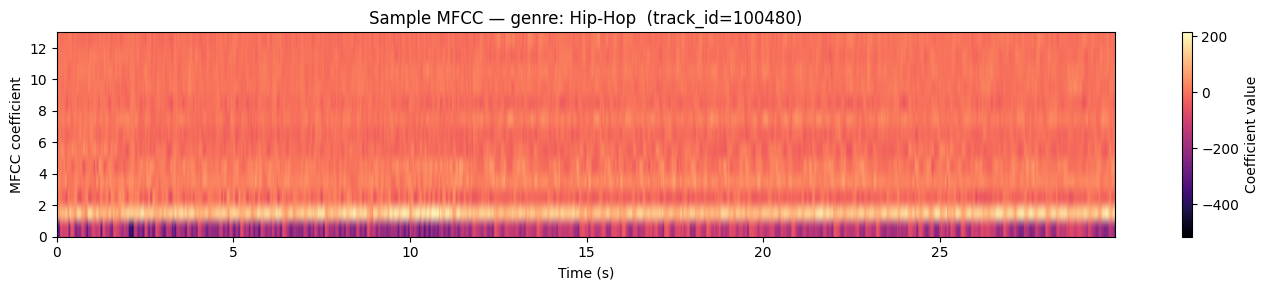

⏱  MFCC sample plot : 0.79s


In [8]:
_t0 = _time_module.perf_counter()

# ── Visualise one example MFCC from the training set ─────────────────────────
idx_row = 0
row = train_index_u.iloc[idx_row]
mfcc = np.load(row["mfcc_path"])
genre = row["genre_top"]

fig, ax = plt.subplots(figsize=(14, 3))
img = ax.imshow(mfcc, aspect="auto", origin="lower",
                extent=[0, N_FRAMES * HOP_LENGTH / SAMPLE_RATE, 0, N_MFCC],
                cmap="magma")
ax.set_title(f"Sample MFCC — genre: {genre}  (track_id={row['track_id']})")
ax.set_xlabel("Time (s)")
ax.set_ylabel("MFCC coefficient")
plt.colorbar(img, ax=ax, label="Coefficient value")
plt.tight_layout()
plt.show()

_section_times["4b. MFCC plot"] = _time_module.perf_counter() - _t0
print(f"⏱  MFCC sample plot : {_section_times['4b. MFCC plot']:.2f}s")


## 5. Preprocessing

1. **Add channel dimension** — Conv2D expects `(N, H, W, C)`, so reshape `(N, 13, 2582)` → `(N, 13, 2582, 1)`.
2. **Standardise** — compute per-MFCC-coefficient mean and std over the training set; apply to val and test.
   This prevents any information from val/test leaking into normalisation statistics.
3. **One-hot encode** labels for `categorical_crossentropy`.

In [9]:
_t0 = _time_module.perf_counter()

# ── Label encoding ───────────────────────────────────────────────────────────
train_index_u["label_int"] = label_enc.transform(train_index_u["genre_top"].to_numpy())
val_index_u["label_int"]   = label_enc.transform(val_index_u["genre_top"].to_numpy())
test_index_u["label_int"]  = label_enc.transform(test_index_u["genre_top"].to_numpy())

# ── Compute per-coefficient mean/std over TRAIN (streaming, no big X_train RAM) ──
def compute_train_stats(index_df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    sum_c   = np.zeros((N_MFCC,), dtype=np.float64)
    sumsq_c = np.zeros((N_MFCC,), dtype=np.float64)
    count = 0

    for i, p in enumerate(index_df["mfcc_path"]):
        x = np.load(p)  # (13, 2582)
        sum_c   += x.sum(axis=1)
        sumsq_c += (x * x).sum(axis=1)
        count   += x.shape[1]
        if (i + 1) % 2000 == 0:
            print(f"  stats pass: {i+1}/{len(index_df)}")

    mean = sum_c / max(1, count)
    var  = (sumsq_c / max(1, count)) - mean**2
    std  = np.sqrt(np.maximum(var, 1e-12))

    mu  = mean.reshape((1, N_MFCC, 1, 1)).astype(np.float32)
    sig = std.reshape((1, N_MFCC, 1, 1)).astype(np.float32)
    return mu, sig

print("Computing training mean/std (streaming) …")
mu, std = compute_train_stats(train_index_u)
print(f"mu shape={mu.shape}, std shape={std.shape}")

# ── tf.data input pipeline ───────────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE
mu_tf  = tf.constant(mu, dtype=tf.float32)
std_tf = tf.constant(std, dtype=tf.float32)

def _np_load_mfcc(path_bytes):
    path = path_bytes.decode("utf-8")
    x = np.load(path).astype(np.float32, copy=False)  # (13, 2582)
    x = x[..., np.newaxis]                            # (13, 2582, 1)
    return x

def make_dataset(index_df: pd.DataFrame, batch_size: int, shuffle: bool) -> tf.data.Dataset:
    paths  = index_df["mfcc_path"].to_numpy(dtype=str)
    labels = index_df["label_int"].to_numpy(dtype=np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(paths), 10_000), seed=SEED, reshuffle_each_iteration=True)

    def _load_and_norm(path, y):
        x = tf.numpy_function(_np_load_mfcc, [path], Tout=tf.float32)
        x.set_shape((*MFCC_SHAPE, 1))
        x = (x - mu_tf[0]) / std_tf[0]
        y_oh = tf.one_hot(y, N_CLASSES)
        return x, y_oh

    ds = ds.map(_load_and_norm, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_index_u, BATCH_SIZE, shuffle=True)
val_ds   = make_dataset(val_index_u,   BATCH_SIZE, shuffle=False)
test_ds  = make_dataset(test_index_u,  BATCH_SIZE, shuffle=False)

print("Datasets ready:")
print(f"  train batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"  val   batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"  test  batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

_section_times["5. Preprocessing (refactor)"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Preprocessing : {_section_times['5. Preprocessing (refactor)']:.2f}s")


Computing training mean/std (streaming) …
  stats pass: 2000/2951
mu shape=(1, 13, 1, 1), std shape=(1, 13, 1, 1)
Datasets ready:
  train batches: 185
  val   batches: 28
  test  batches: 28

⏱  Preprocessing : 25.71s


## 6. Build the CNN Model

Direct Keras translation of the original FMA architecture.
No batch normalisation, no dropout — kept faithful to the original paper.

In [10]:
_t0 = _time_module.perf_counter()

def build_model(n_classes: int) -> keras.Model:
    """2D CNN on MFCC spectrograms — faithful to FMA baselines.ipynb §3.1.

    Conv2D(3,  (13,10), stride (1,4)) → (1,  644,  3)
    Conv2D(15, (1, 10), stride (1,4)) → (1,  159, 15)
    Conv2D(65, (1, 10), stride (1,4)) → (1,   38, 65)
    Flatten                           → (2470,)
    Dense(n_classes, softmax)
    """
    inputs = keras.Input(shape=(*MFCC_SHAPE, 1), name="mfcc")   # (13, 2582, 1)

    x = layers.Conv2D(3,  (13, 10), strides=(1, 4), padding="valid",
                      activation="relu", name="conv1")(inputs)
    x = layers.Conv2D(15, (1,  10), strides=(1, 4), padding="valid",
                      activation="relu", name="conv2")(x)
    x = layers.Conv2D(65, (1,  10), strides=(1, 4), padding="valid",
                      activation="relu", name="conv3")(x)
    x = layers.Flatten(name="flatten")(x)
    outputs = layers.Dense(n_classes, activation="softmax", name="fc_out")(x)

    return keras.Model(inputs, outputs, name="mfcc_2dcnn_baseline")


with tf.device(RUNTIME_DEVICE):
    model = build_model(N_CLASSES)

model.summary()

_section_times["6. Build model"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Build model : {_section_times['6. Build model']:.2f}s")

Model: "mfcc_2dcnn_baseline"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mfcc (InputLayer)           [(None, 13, 2582, 1)]     0         
                                                                 
 conv1 (Conv2D)              (None, 1, 644, 3)         393       
                                                                 
 conv2 (Conv2D)              (None, 1, 159, 15)        465       
                                                                 
 conv3 (Conv2D)              (None, 1, 38, 65)         9815      
                                                                 
 flatten (Flatten)           (None, 2470)              0         
                                                                 
 fc_out (Dense)              (None, 8)                 19768     
                                                                 
Total params: 30441 (118.91 KB)
Trainable param

## 7. Compile & Train

Optimizer, loss, and epoch count are identical to the original FMA baseline.
`shuffle=True` is set to randomise the order within each epoch.

In [11]:
import datetime as _dt
import json as _json

_t0 = _time_module.perf_counter()

# ── Stamped run directory ─────────────────────────────────────────────────────
# Created here (not in the config cell) so the timestamp reflects when training
# actually started, not when the notebook was opened.
# Format: mfcc-cnn-<yyyymmdd-HHMMSS>  (no colons — invalid on Windows/NTFS)
_run_ts = _dt.datetime.now().strftime("%Y%m%d-%H%M%S")
RUN_DIR = MODELS_BASE_DIR / f"mfcc-cnn-{_run_ts}"
RUN_DIR.mkdir(parents=True, exist_ok=True)
print(f"Run directory : {RUN_DIR}")

with tf.device(RUNTIME_DEVICE):
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

print(f"Training on {RUNTIME_DEVICE}  |  epochs={EPOCHS}, batch_size={BATCH_SIZE}\n")

with tf.device(RUNTIME_DEVICE):
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
    )

# ── Best-epoch summary (survives output clearing) ─────────────────────────────
best = min(range(len(history.history["val_loss"])),
           key=lambda i: history.history["val_loss"][i])
print(f"\nBest epoch : {best + 1} / {EPOCHS}")
for k in ["loss", "accuracy", "val_loss", "val_accuracy"]:
    print(f"  {k:<16}: {history.history[k][best]:.4f}")

_section_times["7. Compile & train (refactor)"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Compile & train : {_section_times['7. Compile & train (refactor)']:.1f}s  "
      f"({_section_times['7. Compile & train (refactor)']/EPOCHS:.1f}s per epoch)")

# ── Save model ────────────────────────────────────────────────────────────────
model_path = RUN_DIR / "baseline_mfcc_cnn.keras"
model.save(str(model_path))
print(f"Model saved  → {model_path}")

# ── Save normalization stats (for the inference module) ───────────────────────
_norm_path = RUN_DIR / "norm_stats.npz"
np.savez(
    str(_norm_path),
    mu=mu,
    std=std,
    genre_classes=np.array(GENRE_CLASSES),
)
print(f"Norm stats   → {_norm_path}")

# ── Build & save JSON run report ───────────────────────────────────────────────
# Section 9 loads this file and fills in "evaluation" with per-split metrics.
_hist    = history.history
_n_ep    = len(_hist["loss"])
_t_train = _section_times["7. Compile & train (refactor)"]

# Capture model.summary() as a single string
_summary_lines = []
model.summary(print_fn=lambda l: _summary_lines.append(l))

_report = {
    "run_id":       f"mfcc-cnn-{_run_ts}",
    "subset":       SUBSET,
    "generated_at": _dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_file":   model_path.name,
    "config": {
        "device":        RUNTIME_DEVICE,
        "audio_backend": AUDIO_BACKEND,
        "num_workers":   NUM_WORKERS,
        "mfcc_extraction": {
            "sample_rate":  SAMPLE_RATE,
            "n_mfcc":       N_MFCC,
            "n_fft":        N_FFT,
            "hop_length":   HOP_LENGTH,
            "n_frames":     N_FRAMES,
            "mfcc_shape":   list(MFCC_SHAPE),
            "cache_shared": MFCC_CACHE_SHARED,
        },
        "training": {
            "epochs":     EPOCHS,
            "batch_size": BATCH_SIZE,
            "optimizer":  "SGD",
            "lr":         1e-3,
            "loss":       "categorical_crossentropy",
        },
    },
    "dataset": {
        "n_classes":     N_CLASSES,
        "genres":        GENRE_CLASSES,
        "train_samples": len(train_index_u),
        "val_samples":   len(val_index_u),
        "test_samples":  len(test_index_u),
    },
    "model_architecture": {
        "name":         model.name,
        "total_params": model.count_params(),
        "summary":      "\n".join(_summary_lines),
    },
    "training_history": {
        "epochs": [
            {
                "epoch":        i + 1,
                "loss":         float(_hist["loss"][i]),
                "accuracy":     float(_hist["accuracy"][i]),
                "val_loss":     float(_hist["val_loss"][i]),
                "val_accuracy": float(_hist["val_accuracy"][i]),
            }
            for i in range(_n_ep)
        ],
        "best_epoch": {
            "epoch":        best + 1,
            "loss":         float(_hist["loss"][best]),
            "accuracy":     float(_hist["accuracy"][best]),
            "val_loss":     float(_hist["val_loss"][best]),
            "val_accuracy": float(_hist["val_accuracy"][best]),
        },
        "timing_seconds":    round(_t_train, 2),
        "seconds_per_epoch": round(_t_train / _n_ep, 2),
    },
    "evaluation": None,   # filled in by Section 9
}

REPORT_PATH = RUN_DIR / f"run_report_{SUBSET}.json"
REPORT_PATH.write_text(_json.dumps(_report, indent=2))
print(f"Run report   → {REPORT_PATH}")

Run directory : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/models/mfcc-cnn-20260313-154739
Training on /XPU:0  |  epochs=30, batch_size=16

Epoch 1/30


2026-03-13 15:47:41.189217: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type XPU is enabled.


onednn_verbose,v1,info,oneDNN v3.8.0 (commit 5dc2e69f319ab59520c9096436488c11ab86fd93)
onednn_verbose,v1,info,cpu,runtime:DPC++,nthr:1
onednn_verbose,v1,info,cpu,isa:Intel AVX2 with Intel DL Boost, float16 and bfloat16 support
onednn_verbose,v1,info,gpu,runtime:DPC++
onednn_verbose,v1,info,cpu,engine,sycl cpu device count:1 
onednn_verbose,v1,info,cpu,engine,0,backend:OpenCL,name:Intel(R) Core(TM) Ultra 9 288V,driver_version:2026.20.1
onednn_verbose,v1,info,gpu,engine,sycl gpu device count:1 
onednn_verbose,v1,info,gpu,engine,0,backend:Level Zero,name:Intel(R) Graphics [0x64a0],driver_version:1.14.37020,binary_kernels:enabled
onednn_verbose,v1,info,graph,backend,0:dnnl_backend
onednn_verbose,v1,info,experimental features are enabled
onednn_verbose,v1,info,use batch_normalization stats one pass is enabled
onednn_verbose,v1,info,GPU convolution v2 is disabled
onednn_verbose,v1,info,experimental functionality for sparse domain is enabled
onednn_verbose,v1,primitive,info,template:operation

## 8. Training History

Plot accuracy and loss curves over epochs for both train and validation sets.
A growing gap between the two curves signals overfitting.

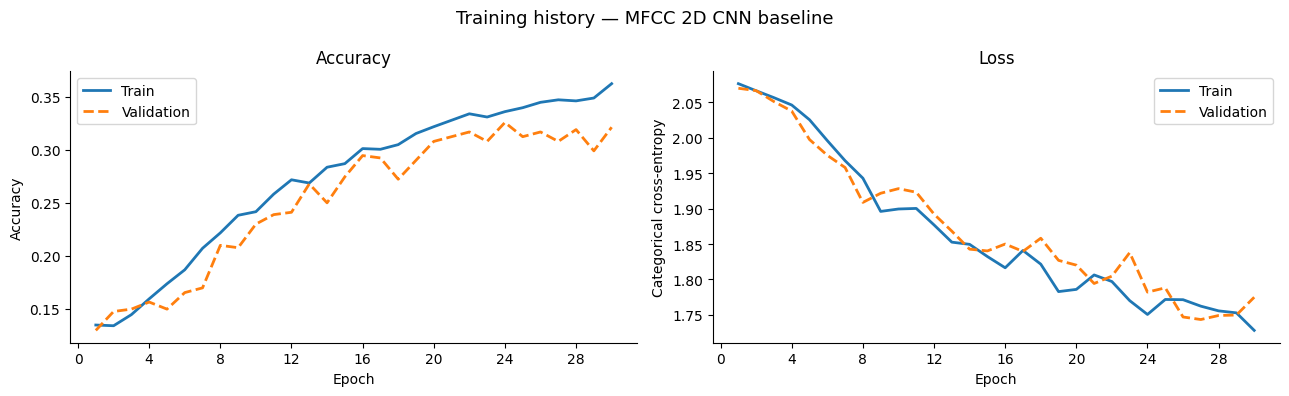

Final train accuracy : 0.3626  (36.26%)
Final val   accuracy : 0.3214  (32.14%)

⏱  Training history plot : 0.51s


In [12]:
_t0 = _time_module.perf_counter()

hist = history.history
epochs_range = range(1, len(hist["accuracy"]) + 1)

fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(13, 4))

# Accuracy
ax_acc.plot(epochs_range, hist["accuracy"],     label="Train",      linewidth=2)
ax_acc.plot(epochs_range, hist["val_accuracy"], label="Validation", linewidth=2, linestyle="--")
ax_acc.set_title("Accuracy")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy")
ax_acc.legend()
ax_acc.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for spine in ["top", "right"]:
    ax_acc.spines[spine].set_visible(False)

# Loss
ax_loss.plot(epochs_range, hist["loss"],     label="Train",      linewidth=2)
ax_loss.plot(epochs_range, hist["val_loss"], label="Validation", linewidth=2, linestyle="--")
ax_loss.set_title("Loss")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Categorical cross-entropy")
ax_loss.legend()
ax_loss.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for spine in ["top", "right"]:
    ax_loss.spines[spine].set_visible(False)

fig.suptitle("Training history — MFCC 2D CNN baseline", fontsize=13)
plt.tight_layout()
plt.show()

final_train_acc = hist["accuracy"][-1]
final_val_acc   = hist["val_accuracy"][-1]
print(f"Final train accuracy : {final_train_acc:.4f}  ({final_train_acc:.2%})")
print(f"Final val   accuracy : {final_val_acc:.4f}  ({final_val_acc:.2%})")

_section_times["8. Training history plot"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Training history plot : {_section_times['8. Training history plot']:.2f}s")


## 9. Evaluate the Model

Report accuracy, Macro-F1, and per-genre F1 on all three splits.
Results are written into `run_report_{SUBSET}.json` in the run directory — the same
file created by Section 7, under the `"evaluation"` key.

### Evaluation loop: `model(xb, training=False)` vs `model.predict(xb)`

`model.predict()` is designed for **whole-dataset** inference: it wraps its input in
an internal `tf.data` pipeline, handles batching, and manages progress callbacks.
When called **once per batch** inside a manual loop, that scaffolding overhead fires
on every iteration — wasted work with no benefit.

`model(xb, training=False)` is the raw Keras **call** interface: it runs a single
forward pass with no extra machinery, then returns a plain tensor. Results are
numerically identical; the only difference is speed.

| Call style | When to use |
|---|---|
| `model.predict(ds)` | Full-dataset inference in one call — preferred when you don't need intermediate access to batches |
| `model(xb, training=False)` | Manual batch loop — avoids per-call dispatch overhead |


In [13]:

import json as _json

_t0 = _time_module.perf_counter()

def eval_dataset(model, ds: tf.data.Dataset, genre_classes, split_label: str):
    # Returns (formatted_block, y_true_int, y_pred_int, metrics_dict).
    # metrics_dict has "cost", "accuracy", "macro_f1", and "per_genre" keyed by genre name.
    #
    # NOTE: model(xb, training=False) instead of model.predict(xb) — avoids the
    # internal tf.data scaffolding overhead that fires on every per-batch call.

    # ── Cost (aggregate loss over the full split) ──────────────────────────────
    # model.evaluate() runs the compiled loss (CategoricalCrossentropy) over
    # every batch in `ds` and returns the mean — this is the "cost" for the split.
    eval_results = model.evaluate(ds, verbose=0, return_dict=True)
    cost = float(eval_results.get("loss", float("nan")))

    y_true, y_pred = [], []
    for xb, yb in ds:
        pred = model(xb, training=False).numpy()
        y_pred.append(np.argmax(pred, axis=1))
        y_true.append(np.argmax(yb.numpy(), axis=1))
    y_true = np.concatenate(y_true) if y_true else np.array([], dtype=np.int64)
    y_pred = np.concatenate(y_pred) if y_pred else np.array([], dtype=np.int64)

    acc      = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    cr_text  = classification_report(y_true, y_pred,
                                     target_names=genre_classes, zero_division=0)
    cr_dict  = classification_report(y_true, y_pred,
                                     target_names=genre_classes, zero_division=0,
                                     output_dict=True)
    block = (
        f"\n{'='*60}\n {split_label}\n{'='*60}\n"
        f"  Cost     : {cost:.4f}  (CategoricalCrossentropy)\n"
        f"  Accuracy : {acc:.4f}  ({acc:.2%})\n"
        f"  Macro-F1 : {macro_f1:.4f}\n\n"
        f"Per-genre classification report:\n{cr_text}"
    )
    print(block)

    # Per-genre structured metrics (sklearn adds "accuracy", "macro avg", etc. —
    # keep only the actual genre entries)
    per_genre = {
        g: {k: round(float(v), 4) for k, v in cr_dict[g].items()}
        for g in genre_classes
        if g in cr_dict
    }
    metrics = {
        "cost":      round(cost, 4),
        "accuracy":  round(float(acc), 4),
        "macro_f1":  round(float(macro_f1), 4),
        "per_genre": per_genre,
    }
    return block, y_true, y_pred, metrics


with tf.device(RUNTIME_DEVICE):
    train_block, y_train_true, y_train_pred, train_metrics = eval_dataset(
        model, train_ds, GENRE_CLASSES, "TRAIN SET")
    val_block,   y_val_true,   y_val_pred,   val_metrics   = eval_dataset(
        model, val_ds,   GENRE_CLASSES, "VALIDATION SET")
    test_block,  y_test_true,  y_test_pred,  test_metrics  = eval_dataset(
        model, test_ds,  GENRE_CLASSES, "TEST SET")

_section_times["9. Evaluation (refactor)"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Evaluation : {_section_times['9. Evaluation (refactor)']:.2f}s")

# ── Cost summary across splits ─────────────────────────────────────────────────
print("\nCost summary (CategoricalCrossentropy):")
for label, m in [("train", train_metrics), ("val  ", val_metrics), ("test ", test_metrics)]:
    print(f"  {label}  cost={m['cost']:.4f}  acc={m['accuracy']:.4f}  macro-f1={m['macro_f1']:.4f}")

# ── Update JSON run report with evaluation results ────────────────────────────
_report = _json.loads(REPORT_PATH.read_text())
_report["evaluation"] = {
    "timing_seconds": round(_section_times["9. Evaluation (refactor)"], 2),
    "splits": {
        "train":      train_metrics,
        "validation": val_metrics,
        "test":       test_metrics,
    },
}
REPORT_PATH.write_text(_json.dumps(_report, indent=2))
print(f"Report updated → {REPORT_PATH}")



 TRAIN SET
  Cost     : 1.7198  (CategoricalCrossentropy)
  Accuracy : 0.3555  (35.55%)
  Macro-F1 : 0.3307

Per-genre classification report:
               precision    recall  f1-score   support

   Electronic       0.36      0.20      0.25       368
 Experimental       0.26      0.19      0.22       369
         Folk       0.38      0.34      0.36       369
      Hip-Hop       0.37      0.54      0.44       369
 Instrumental       0.35      0.61      0.45       369
International       0.38      0.22      0.27       369
          Pop       0.22      0.12      0.15       369
         Rock       0.41      0.63      0.50       369

     accuracy                           0.36      2951
    macro avg       0.34      0.36      0.33      2951
 weighted avg       0.34      0.36      0.33      2951


 VALIDATION SET
  Cost     : 1.7491  (CategoricalCrossentropy)
  Accuracy : 0.3214  (32.14%)
  Macro-F1 : 0.2956

Per-genre classification report:
               precision    recall  f1-score  

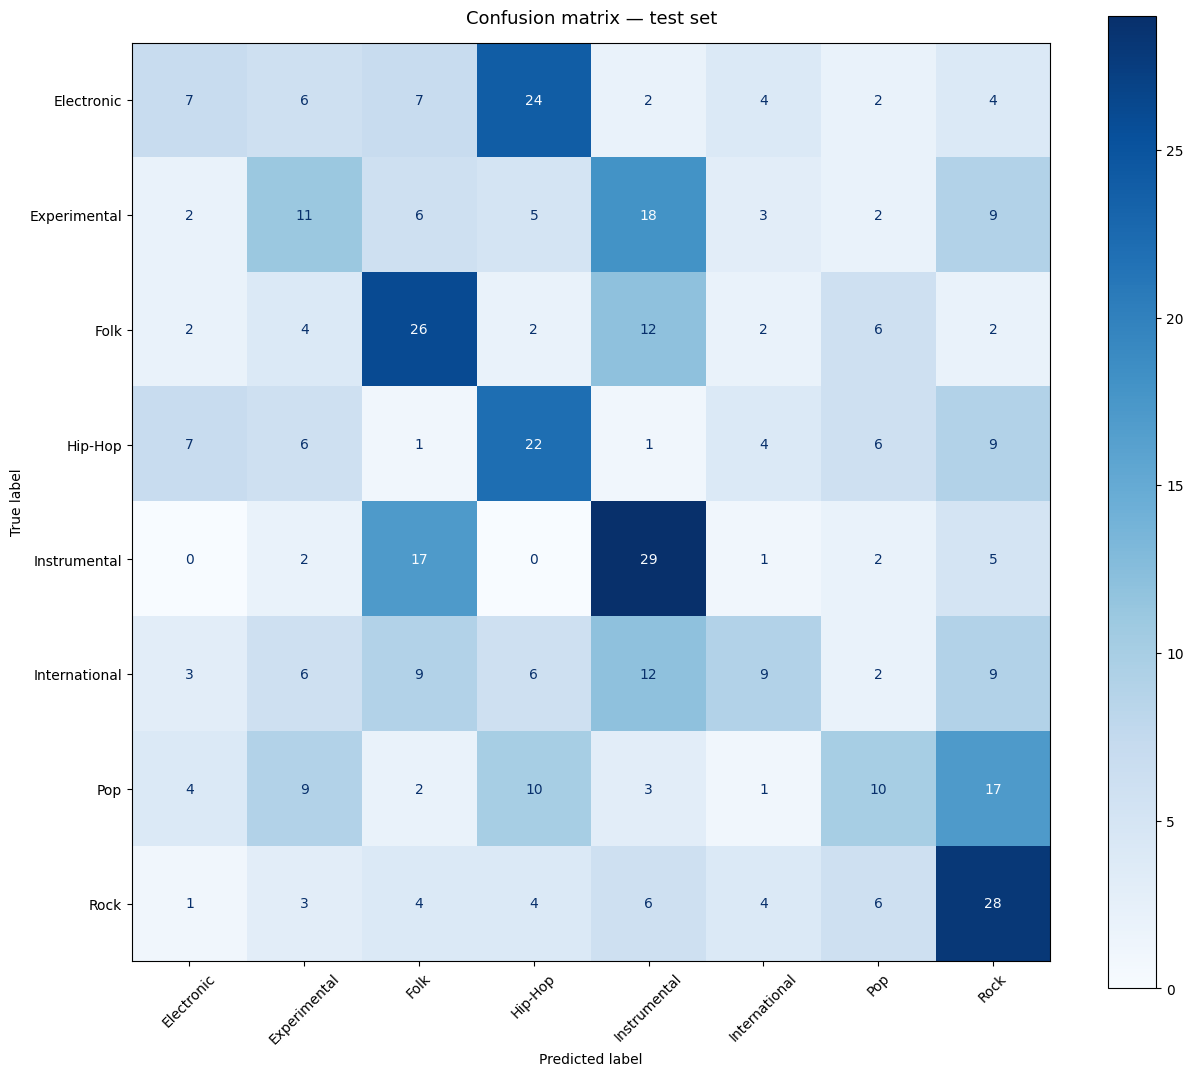

⏱  Confusion matrix : 3.80s


In [14]:
_t0 = _time_module.perf_counter()

# ── Confusion matrix (test set) ───────────────────────────────────────────────
cm = confusion_matrix(y_test_true, y_test_pred)

fig, ax = plt.subplots(figsize=(13, 11))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GENRE_CLASSES)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap="Blues", values_format="d")
ax.set_title("Confusion matrix — test set", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

_section_times["9b. Confusion matrix (refactor)"] = _time_module.perf_counter() - _t0
print(f"⏱  Confusion matrix : {_section_times['9b. Confusion matrix (refactor)']:.2f}s")


## 10. Predict on a New Audio Sample

Set `INFER_PATH` to any MP3 file to predict its genre with the trained model.
By default this cell re-uses a random sample from the test set so it runs without
additional files.


Predicted genre : Electronic  (confidence: 21.93%)
True genre      : ?


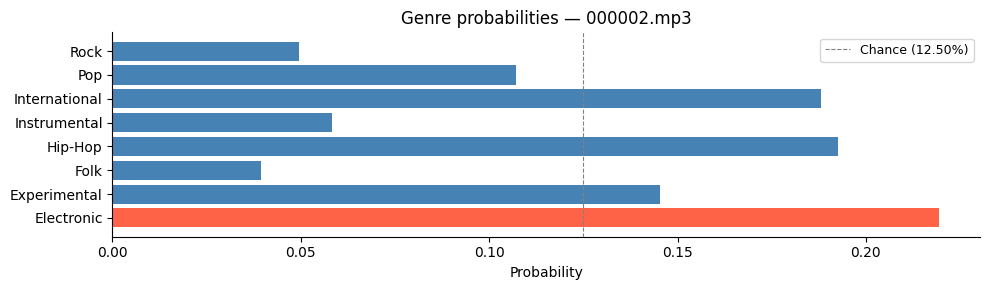


⏱  Inference : 124.18s


In [15]:
_t0 = _time_module.perf_counter()

INFER_PATH = "../../FMA/fma_medium/000/000002.mp3"   # e.g. Path("/path/to/my_track.mp3")

if INFER_PATH is None:
    rng_idx    = np.random.randint(len(test_df))
    INFER_PATH = Path(test_df.iloc[rng_idx]["filepath"])
    true_genre = test_df.iloc[rng_idx]["genre_top"]
    print(f"Using test sample: {INFER_PATH.name}  (true genre: {true_genre})")
else:
    INFER_PATH = Path(INFER_PATH)
    true_genre = "?"

try:
    y = _load_audio_simple(INFER_PATH, sr=SAMPLE_RATE, mono=True, duration=30.0)
    ok, reason = _sanity_check_audio(y, SAMPLE_RATE)
    if not ok:
        raise ValueError(f"sanity_check_failed:{reason}")
    mfcc = _mfcc_fixed_shape(y)
except Exception as exc:
    print(f"Could not load/extract MFCC: {exc}")
    mfcc = None

if mfcc is not None:
    x_infer = ((mfcc[np.newaxis, ..., np.newaxis] - mu) / std).astype(np.float32)

    probs      = model.predict(x_infer, verbose=0)[0]
    pred_idx   = int(np.argmax(probs))
    pred_genre = GENRE_CLASSES[pred_idx]
    confidence = float(probs[pred_idx])

    print(f"\nPredicted genre : {pred_genre}  (confidence: {confidence:.2%})")
    print(f"True genre      : {true_genre}")

    fig, ax = plt.subplots(figsize=(10, 3))
    colors = ["steelblue" if g != pred_genre else "tomato" for g in GENRE_CLASSES]
    ax.barh(GENRE_CLASSES, probs, color=colors)
    ax.set_xlabel("Probability")
    ax.set_title(f"Genre probabilities — {INFER_PATH.name}")
    ax.axvline(1 / N_CLASSES, color="grey", linestyle="--", linewidth=0.8,
               label=f"Chance ({1/N_CLASSES:.2%})")
    ax.legend(fontsize=9)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()

_section_times["10. Inference (refactor)"] = _time_module.perf_counter() - _t0
print(f"\n⏱  Inference : {_section_times['10. Inference (refactor)']:.2f}s")


---

## Runtime Summary

In [16]:
_total = _time_module.perf_counter() - _T0

SEP = "=" * 52
print(SEP)
print("  Runtime summary")
print(SEP)
for section, elapsed in _section_times.items():
    bar_len  = max(1, int(elapsed / _total * 30))
    bar      = "█" * bar_len
    pct      = elapsed / _total * 100
    mins, secs = divmod(elapsed, 60)
    time_str = f"{int(mins)}m {secs:04.1f}s" if mins else f"{elapsed:6.1f}s"
    print(f"  {section:<28}  {time_str:>9}  {pct:5.1f}%  {bar}")

print(SEP)
mins_total, secs_total = divmod(_total, 60)
total_str = f"{int(mins_total)}m {secs_total:04.1f}s" if mins_total else f"{_total:.1f}s"
print(f"  {'TOTAL':<28}  {total_str:>9}")
print(SEP)

  Runtime summary
  2. Device setup                   14.9s    0.8%  █
  3. Load manifest                   1.1s    0.1%  █
  3b. Genre plot                     2.0s    0.1%  █
  4. MFCC extraction (refactor)  14m 02.5s   47.9%  ██████████████
  4b. MFCC plot                      0.8s    0.0%  █
  5. Preprocessing (refactor)       25.7s    1.5%  █
  6. Build model                     0.9s    0.0%  █
  7. Compile & train (refactor)  11m 39.1s   39.7%  ███████████
  8. Training history plot           0.5s    0.0%  █
  9. Evaluation (refactor)          42.8s    2.4%  █
  9b. Confusion matrix (refactor)       3.8s    0.2%  █
  10. Inference (refactor)       2m 04.2s    7.1%  ██
  TOTAL                         29m 19.1s


---

# Performance Engineering: From MFCC Pipeline v2 → v5

## 1. Background

Version 2 of the MFCC pipeline (MelCNN-MGR/model_training/baseline_mfcc_cnn_v2.ipynb) implemented a functional baseline for music genre classification using the **FMA dataset**. The system successfully:

* Loads MP3 audio clips
* Extracts **Mel-frequency cepstral coefficients (MFCC)**
* Builds train / validation / test datasets
* Trains a CNN classifier

While the system works correctly, experiments revealed that **feature extraction became the dominant performance bottleneck**, especially when scaling from small subsets to larger datasets such as **FMA-medium**.

In practice, **MFCC extraction time greatly exceeded model training time**, making experimentation slow and inefficient.

Therefore, **Story 2 focuses on performance optimization of the data pipeline**, transforming Version 2 into Version 3.

---

# 2. Version 2 Pipeline Architecture

Version 2 processes MFCC features in the following way.

### Version 2 Architecture

```mermaid
flowchart TD

A[MP3 File] --> B[librosa.load]
B --> C[Capture stderr logs from decoder]
C --> D[MFCC computation]
D --> E[Append MFCC to Python list]
E --> F[np.stack all features]
F --> G[Large in-memory array]
G --> H[Save cache file: X_train.npy]
H --> I[CNN training]
```

### Processing Workflow

For each dataset split (train / validation / test):

1. Iterate through dataset metadata
2. Load MP3 audio using `librosa.load`
3. Capture **decoder stderr output** to detect degraded MP3 frames
4. Compute MFCC features
5. Append features to a Python list
6. Stack all MFCC arrays into a large tensor
7. Save cached feature arrays

While conceptually simple, this design introduces several **performance and scalability issues**.

---

# 3. Performance Issues Identified in Version 2

## 3.1 Sequential Processing

MFCC extraction runs **file-by-file in a single thread**.

```
for each audio file:
    decode mp3
    compute mfcc
```

Modern CPUs provide multiple cores, but Version 2 only uses one.

**Result**

* CPU underutilization
* Slow feature extraction

---

## 3.2 Expensive stderr Capture

Version 2 captures **C-level decoder stderr logs** for every file to detect warnings such as:

```
dequantization failed
```

This requires:

* redirecting file descriptors
* capturing stderr pipes
* scanning log messages

Even though most files are clean, the capture occurs **for every audio file**.

**Result**

* additional OS-level overhead
* unnecessary processing

---

## 3.3 Large In-Memory Feature Assembly

MFCC arrays are first accumulated in Python lists.

```
Xs.append(mfcc)
...
X = np.stack(Xs)
```

When the dataset becomes large:

* memory usage spikes
* `np.stack()` becomes expensive
* system may experience memory pressure

---

## 3.4 Repeated MP3 Decoding

Every experiment re-runs the entire pipeline:

```
MP3 decode
MFCC compute
repeat
```

However, the audio content **does not change between experiments**.

**Result**

* repeated expensive decoding
* slow iteration cycles

---

# 4. Design Goals for Version 3

Version 3 aims to significantly improve performance while keeping the system simple and notebook-friendly.

The key goals are:

1. Remove unnecessary overhead
2. Utilize multi-core CPUs
3. Avoid large in-memory feature arrays
4. Cache feature extraction results
5. Enable faster experimentation

---

# 5. Version 3 Architecture

Version 3 introduces a redesigned feature pipeline.

### Version 3 Architecture

```mermaid
flowchart TD

A[MP3 File] --> B[Parallel MFCC extraction workers]
B --> C[Load audio with librosa]
C --> D[Cheap sanity checks]
D --> E[MFCC computation]
E --> F[Save per-track MFCC cache]
F --> G[cache/mfcc/<track_id>.npy]

G --> H[MFCC index parquet manifest]

H --> I[tf.data streaming loader]
I --> J[Batching and normalization]
J --> K[CNN training]
```

This architecture separates **feature extraction** from **model training**.

---

# 6. Key Improvements in Version 3

## 6.1 Remove stderr Capture

The feature extraction hot path now loads audio directly:

```python
librosa.load(filepath)
```

Unreadable files are still handled safely using:

```python
try:
    load audio
except:
    skip file
```

This eliminates expensive stderr capture operations while preserving robustness.

---

## 6.2 Add Cheap Sanity Checks

Instead of analyzing decoder logs, Version 3 performs lightweight validation checks on the waveform.

Examples include:

* detecting NaN or infinite values
* verifying minimum audio duration
* optionally skipping near-silent signals

Example:

```python
if not np.isfinite(y).all():
    skip
```

These checks are extremely fast and sufficient for filtering problematic audio.

---

## 6.3 Parallel MFCC Extraction

Version 3 introduces **multiprocessing** using:

```
ProcessPoolExecutor
```

Each worker independently processes an audio file:

```
load audio
compute MFCC
save MFCC
```

**Benefits**

* fully utilizes multi-core CPUs
* dramatically reduces preprocessing time

---

## 6.4 Per-Track MFCC Cache

Instead of constructing a single large array, MFCC features are stored per track.

```
cache/
  mfcc/
    train/
      000123.npy
      000124.npy
    validation/
    test/
```

Each file stores:

```
shape: (N_MFCC, N_FRAMES)
dtype: float32
```

**Advantages**

* avoids large memory allocations
* enables restartable extraction
* eliminates repeated decoding across experiments

---

## 6.5 Metadata Index (Parquet)

A manifest file is generated alongside the MFCC cache.

Example:

```
cache/mfcc_index_train.parquet
```

Columns include:

| column    | description          |
| --------- | -------------------- |
| track_id  | FMA track identifier |
| filepath  | original MP3 path    |
| mfcc_path | cached MFCC file     |
| split     | dataset split        |
| label     | genre label          |
| status    | ok / skipped         |
| reason    | error reason         |

This provides a clean interface between **data preprocessing and model training**.

---

## 6.6 Streaming Training Data Loader

Training now uses **TensorFlow's tf.data pipeline** instead of loading entire datasets into memory.

Data flow:

```
mfcc_path
    ↓
np.load()
    ↓
normalization
    ↓
batch
    ↓
prefetch
```

**Benefits**

* small memory footprint
* efficient CPU/GPU overlap
* scalable to larger datasets

---

# 7. Version 2 vs Version 3 Comparison

| Feature               | Version 2         | Version 3       |
| --------------------- | ----------------- | --------------- |
| MFCC extraction       | single-thread     | parallel        |
| stderr handling       | captured per file | removed         |
| feature storage       | large arrays      | per-track cache |
| memory usage          | high              | low             |
| restart capability    | none              | resumable       |
| experiment speed      | slow              | fast            |
| training data loading | full array        | streaming       |

---

# 8. Performance Insight

A key insight from this optimization is that **model training is often not the bottleneck**.

Instead, the slow stage is frequently **data preparation and feature extraction**.

Version 3 applies a common ML engineering pattern:

```
Expensive preprocessing
        ↓
Feature cache
        ↓
Fast experimentation
```

Once features are cached, experiments can iterate rapidly without touching the raw dataset again.

---

# 9. Conceptual Lesson

Version 3 demonstrates a core machine learning engineering principle:

> Separate expensive preprocessing from model experimentation.

This approach improves:

* development velocity
* reproducibility
* system scalability

---

# 10. Summary

Version 2 provided a correct baseline MFCC pipeline but suffered from performance limitations due to:

* sequential processing
* heavy stderr capture
* large in-memory feature arrays
* repeated MP3 decoding

Version 3 introduces a redesigned pipeline with:

* multiprocessing extraction
* lightweight audio validation
* per-track MFCC caching
* streaming training data loading

These improvements transform the system into a **scalable and efficient feature extraction pipeline suitable for larger datasets and rapid experimentation**.

---

If you'd like, I can also add **one more diagram** that often helps readers:

**Dataset lifecycle diagram**

```
Raw audio
   ↓
Feature extraction (one-time)
   ↓
MFCC cache
   ↓
Fast ML experiments
   ↓
Model improvements
```

It makes the engineering philosophy of Version 3 extremely clear.


# Setup guide (known-good): WSL Ubuntu 24.04 + Arc 140V + Python 3.11 + TF 2.15.1 + ITEX 2.15.0.3

This section is a practical end‑to‑end guide for reproducing the working stack.

## 1) Windows host prerequisites (driver + WSL plumbing)

1. Update WSL (PowerShell as Admin):
   ```powershell
   wsl --update
   wsl --shutdown
   ```
2. Install the **latest Intel Graphics Windows driver** for your Arc/Lunar Lake GPU. Reboot after installing.

WSL uses a Windows-side driver for GPU access, and Linux-in-WSL provides user-space runtimes.

## 2) WSL checks (must pass)

Inside WSL:
```bash
ls -l /dev/dxg
uname -r
```

- If `/dev/dxg` exists: GPU is exposed to WSL.

## 3) Install/verify Intel GPU runtimes in WSL (Level Zero + OpenCL)

Install core runtime packages (many systems already have these when OpenCL/Level Zero works):

```bash
sudo apt update
sudo apt install -y ocl-icd-libopencl1 clinfo intel-opencl-icd libze1
```

Verify OpenCL sees the Intel GPU:
```bash
clinfo | grep -E "Platform Name|Device Name|Device Type" -n | head -n 140
```

## 4) Install oneAPI Base Toolkit (optional but very useful)

If installed, enable it each shell:
```bash
source /opt/intel/oneapi/setvars.sh
```

Check Level Zero / SYCL device visibility:
```bash
sycl-ls
```

You want to see a line like:
`[level_zero:gpu] ... Intel(R) Graphics ...`

## 5) Python venv + pinned packages (the known-good combo)

Create venv:
```bash
python3.11 -m venv .venv_itex
source .venv_itex/bin/activate
python -m pip install -U pip wheel setuptools
```

Install the exact working versions:
```bash
pip install tensorflow==2.15.1
pip install intel-extension-for-tensorflow==2.15.0.3
pip install intel-extension-for-tensorflow-lib==2.15.0.3.2
```

Pin them in `requirements.txt` to avoid accidental breakage.

## 6) Validate TensorFlow sees XPU

```bash
python - <<'PY'
import tensorflow as tf
import intel_extension_for_tensorflow as itex
print("TF:", tf.__version__)
print("ITEX:", itex.__version__)
print("XPU devices:", tf.config.list_physical_devices("XPU"))
PY
```

Expected: `XPU devices: [PhysicalDevice(name='/physical_device:XPU:0', ...)]`

## 7) Smoke test on XPU

```python
import tensorflow as tf
import intel_extension_for_tensorflow as itex

with tf.device("/XPU:0"):
    a = tf.random.normal([2048, 2048])
    b = tf.random.normal([2048, 2048])
    c = tf.matmul(a, b)
    tf.print("matmul ok, shape:", tf.shape(c), "device:", c.device)
```

## 8) Memory controls (optional)

- **Memory growth** (best-effort): `tf.config.experimental.set_memory_growth(...)`
- **Memory cap** (best-effort): `tf.config.set_logical_device_configuration(... memory_limit=...)`

Both must run **before** TensorFlow initializes the device (i.e., before tensors/models are created).
